In [45]:
!pip install tensorflow

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout, Conv1D, MaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler
from tensorflow.keras.optimizers import Adam

In [47]:
df = pd.read_csv('processed_stock_data.csv')

In [48]:
df

,Date,Open,High,Low,Close,Volume,50-day MA,200-day MA,Close_diff,lag_1,lag_7,rolling_mean_7,rolling_std_7
0,2012-01-03,58.485714,58.928570,58.428570,58.747143,75555200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-01-04,58.571430,59.240002,58.468571,59.062859,65005500,NaN,NaN,0.315716,58.747143,NaN,NaN,NaN
2,2012-01-05,59.278572,59.792858,58.952858,59.718571,67817400,NaN,NaN,0.655712,59.062859,NaN,NaN,NaN
3,2012-01-06,59.967144,60.392857,59.888573,60.342857,79573200,NaN,NaN,0.624286,59.718571,NaN,NaN,NaN
4,2012-01-09,60.785713,61.107143,60.192856,60.247143,98506100,NaN,NaN,-0.095714,60.342857,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2006,2019-12-23,280.529999,284.250000,280.369995,283.809289,24643000,259.670586,216.528297,4.369287,279.440002,271.459991,279.775608,2.524879
2007,2019-12-24,284.150718,284.890015,280.977848,283.809289,12119700,260.629372,217.042793,0.000000,283.809289,275.149994,281.012650,1.932721
2008,2019-12-26,284.150718,288.448204,280.977848,283.809289,23280300,261.599157,217.553289,0.000000,283.809289,279.859985,281.576836,2.108589
2009,2019-12-27,284.150718,288.448204,280.977848,283.809289,36566500,262.587943,218.053686,0.000000,283.809289,280.410004,282.062448,2.185120


In [49]:
# Convert 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])
df.head()

,Date,Open,High,Low,Close,Volume,50-day MA,200-day MA,Close_diff,lag_1,lag_7,rolling_mean_7,rolling_std_7
0,2012-01-03,58.485714,58.928570,58.428570,58.747143,75555200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-01-04,58.571430,59.240002,58.468571,59.062859,65005500,NaN,NaN,0.315716,58.747143,NaN,NaN,NaN
2,2012-01-05,59.278572,59.792858,58.952858,59.718571,67817400,NaN,NaN,0.655712,59.062859,NaN,NaN,NaN
3,2012-01-06,59.967144,60.392857,59.888573,60.342857,79573200,NaN,NaN,0.624286,59.718571,NaN,NaN,NaN
4,2012-01-09,60.785713,61.107143,60.192856,60.247143,98506100,NaN,NaN,-0.095714,60.342857,NaN,NaN,NaN


In [50]:
df.dtypes

Date              datetime64[ns]
Open                     float64
High                     float64
Low                      float64
Close                    float64
Volume                     int64
50-day MA                float64
200-day MA               float64
Close_diff               float64
lag_1                    float64
lag_7                    float64
rolling_mean_7           float64
rolling_std_7            float64
dtype: object

In [51]:
df = df[["Date", "Open", "High", "Low", "Close", "Volume"]]
df

,Date,Open,High,Low,Close,Volume
0,2012-01-03,58.485714,58.928570,58.428570,58.747143,75555200
1,2012-01-04,58.571430,59.240002,58.468571,59.062859,65005500
2,2012-01-05,59.278572,59.792858,58.952858,59.718571,67817400
3,2012-01-06,59.967144,60.392857,59.888573,60.342857,79573200
4,2012-01-09,60.785713,61.107143,60.192856,60.247143,98506100
...,...,...,...,...,...,...
2006,2019-12-23,280.529999,284.250000,280.369995,283.809289,24643000
2007,2019-12-24,284.150718,284.890015,280.977848,283.809289,12119700
2008,2019-12-26,284.150718,288.448204,280.977848,283.809289,23280300
2009,2019-12-27,284.150718,288.448204,280.977848,283.809289,36566500


In [52]:
# Calculate technical indicators
def add_technical_features(data):
    # RSI
    delta = data['Close'].diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    data['RSI'] = 100 - (100 / (1 + (gain.rolling(14).mean() / loss.rolling(14).mean())))
    
    # MACD
    exp12 = data['Close'].ewm(span=12, adjust=False).mean()
    exp26 = data['Close'].ewm(span=26, adjust=False).mean()
    data['MACD'] = exp12 - exp26
    data['Signal'] = data['MACD'].ewm(span=9, adjust=False).mean()
    
    # Bollinger Bands
    sma20 = data['Close'].rolling(20).mean()
    std20 = data['Close'].rolling(20).std()
    data['UpperBB'] = sma20 + 2*std20
    data['LowerBB'] = sma20 - 2*std20
    
    return data.dropna()

In [53]:
df = add_technical_features(df)
features = ['Open', 'High', 'Low', 'Close', 'Volume', 'RSI', 'MACD', 'Signal', 'UpperBB', 'LowerBB']

C:\Users\vimal\AppData\Local\Temp\ipykernel_11816\1259722971.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['RSI'] = 100 - (100 / (1 + (gain.rolling(14).mean() / loss.rolling(14).mean())))
C:\Users\vimal\AppData\Local\Temp\ipykernel_11816\1259722971.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['MACD'] = exp12 - exp26
C:\Users\vimal\AppData\Local\Temp\ipykernel_11816\1259722971.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using 

In [54]:
# 2. Preprocessing

In [55]:
# Train-test split (time-series aware)
train_size = int(0.8 * len(df))
train_data = df.iloc[:train_size]
test_data = df.iloc[train_size:]

In [56]:
# Scale data (fit only on training)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train = scaler.fit_transform(train_data[features])
scaled_test = scaler.transform(test_data[features])

In [57]:
# Create sequences with 30-day window
SEQ_LENGTH = 30

In [58]:
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data)-seq_length-1):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length, features.index('Close')])  # Predict Close price
    return np.array(X), np.array(y)

In [59]:
X_train, y_train = create_sequences(scaled_train, SEQ_LENGTH)
X_test, y_test = create_sequences(scaled_test, SEQ_LENGTH)

In [60]:
# 3. Hybrid CNN-LSTM Model

In [61]:
model = Sequential([
    # CNN for local pattern detection
    Conv1D(filters=64, kernel_size=3, activation='relu', 
          input_shape=(SEQ_LENGTH, len(features))),
    MaxPooling1D(pool_size=2),
    
    # Bidirectional LSTM
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.3),
    
    Bidirectional(LSTM(64)),
    Dropout(0.2),
    
    # Dense layers
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

In [62]:
# 4. Training Configuration

In [63]:
# Learning rate scheduler
def lr_scheduler(epoch):
    initial_lr = 0.001
    decay_factor = 0.1
    decay_epochs = 20
    lr = initial_lr * (decay_factor ** (epoch // decay_epochs))
    return lr

In [64]:
# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=15, 
                          restore_best_weights=True)

In [65]:
# Compile
model.compile(optimizer=Adam(learning_rate=0.001),
             loss='mean_squared_error',
             metrics=['mae'])

In [66]:
# 5. Training


history = model.fit(X_train, y_train,
                  epochs=100,
                  batch_size=64,
                  validation_split=0.2,
                  callbacks=[early_stop, LearningRateScheduler(lr_scheduler)],
                  verbose=1)

Epoch 1/100
20/20 [==============================] - 13s 154ms/step - loss: 0.0128 - mae: 0.0786 - val_loss: 0.0080 - val_mae: 0.0731 - lr: 0.0010
Epoch 2/100
20/20 [==============================] - 1s 58ms/step - loss: 0.0023 - mae: 0.0374 - val_loss: 0.0181 - val_mae: 0.1208 - lr: 0.0010
Epoch 3/100
20/20 [==============================] - 1s 57ms/step - loss: 0.0018 - mae: 0.0329 - val_loss: 0.0136 - val_mae: 0.1034 - lr: 0.0010
Epoch 4/100
20/20 [==============================] - 1s 58ms/step - loss: 0.0015 - mae: 0.0298 - val_loss: 0.0192 - val_mae: 0.1263 - lr: 0.0010
Epoch 5/100
20/20 [==============================] - 1s 56ms/step - loss: 0.0012 - mae: 0.0263 - val_loss: 0.0138 - val_mae: 0.1043 - lr: 0.0010
Epoch 6/100
20/20 [==============================] - 1s 56ms/step - loss: 0.0013 - mae: 0.0282 - val_loss: 0.0194 - val_mae: 0.1290 - lr: 0.0010
Epoch 7/100
20/20 [==============================] - 1s 54ms/step - loss: 0.0011 - mae: 0.0252 - val_loss: 0.0136 - val_mae: 0.1

In [67]:
# 6. Evaluation

In [68]:
# Inverse scaling for predictions
def inverse_scale(scaler, data, feature_index):
    dummy = np.zeros(shape=(len(data), len(features)))
    dummy[:, feature_index] = data
    return scaler.inverse_transform(dummy)[:, feature_index]

In [69]:
# Predictions
y_pred = model.predict(X_test)
y_pred_actual = inverse_scale(scaler, y_pred.flatten(), features.index('Close'))
y_test_actual = inverse_scale(scaler, y_test, features.index('Close'))

12/12 [==============================] - 1s 10ms/step


In [70]:
# Metrics
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mae = mean_absolute_error(y_test_actual, y_pred_actual)
print(f'Test RMSE: ${rmse:.2f}')
print(f'Test MAE: ${mae:.2f}')

Test RMSE: $31.44
Test MAE: $26.97


In [71]:
# 7. Visualization

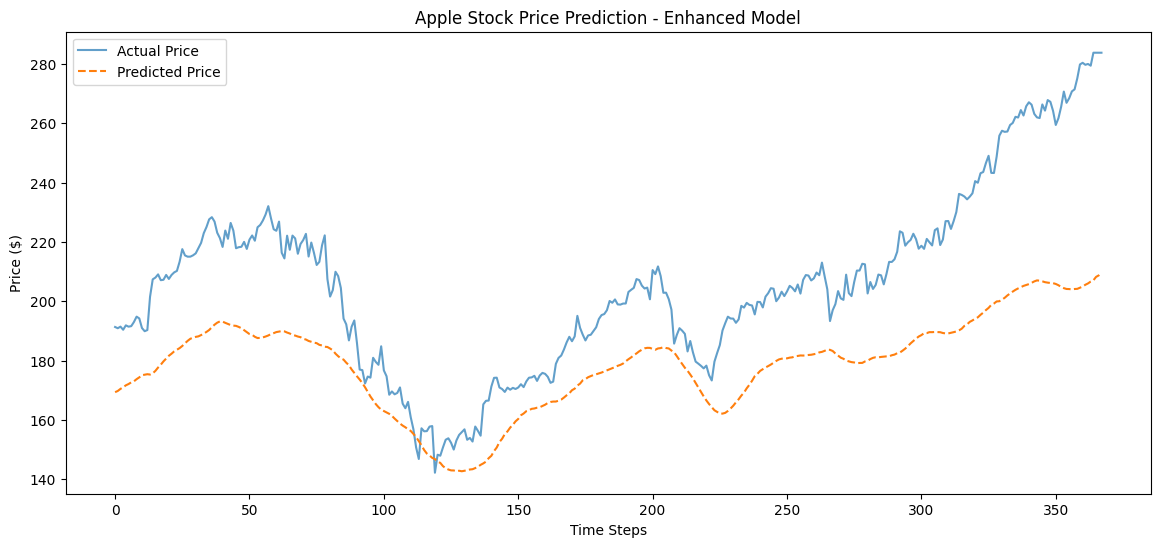

In [72]:
plt.figure(figsize=(14, 6))
plt.plot(y_test_actual, label='Actual Price', alpha=0.7)
plt.plot(y_pred_actual, label='Predicted Price', linestyle='--')
plt.title('Apple Stock Price Prediction - Enhanced Model')
plt.xlabel('Time Steps')
plt.ylabel('Price ($)')
plt.legend()
plt.show()

In [73]:
# 8. Model Summary
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_1 (Conv1D)           (None, 28, 64)            1984      
                                                                 
 max_pooling1d_1 (MaxPooling  (None, 14, 64)           0         
 1D)                                                             
                                                                 
 bidirectional_2 (Bidirectio  (None, 14, 256)          197632    
 nal)                                                            
                                                                 
 dropout_2 (Dropout)         (None, 14, 256)           0         
                                                                 
 bidirectional_3 (Bidirectio  (None, 128)              164352    
 nal)                                                            
                                                      